In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
def load_repo_rate(path, target_index=None):
    raw = pd.read_excel(path, header=None)
    header_row_idx = raw[raw.apply(
        lambda row: row.astype(str).str.contains('Effective Date').any(), axis=1
    )].index[0]
    data = raw.iloc[header_row_idx + 3:].copy()
    data.columns = ['blank', 'eff_date', 'bank_rate', 'repo', 'reverse_repo',
                     'sdf', 'msf', 'crr', 'slr']
    data = data.drop(columns='blank')
    data['eff_date'] = pd.to_datetime(data['eff_date'], errors='coerce')
    data = data.dropna(subset=['eff_date'])
    data['repo'] = pd.to_numeric(data['repo'], errors='coerce')
    repo_changes = data[['eff_date', 'repo']].dropna().sort_values('eff_date')
    repo_changes = repo_changes.set_index('eff_date')['repo']
    repo_changes = repo_changes[~repo_changes.index.duplicated(keep='last')]
    if target_index is not None:
        full_range = pd.date_range(
            start=min(repo_changes.index.min(), target_index.min()),
            end=target_index.max(), freq='D')
        repo_daily = repo_changes.reindex(full_range).ffill().reindex(target_index)
    else:
        repo_daily = repo_changes
    repo_daily.name = 'repo_rate'
    return repo_daily

In [3]:
consolidated = pd.read_excel('C:/Users/Aditi Raj/Downloads/consolidated_macro_daily_2021-07-01_to_2025-12-31_FILLED_v2.xlsx')
consolidated['Date'] = pd.to_datetime(consolidated['Date'])
consolidated = consolidated.rename(columns={
    'SOFR':'sofr', 'USDINR':'usdinr', 'US10Y':'us_10y', 'INDIA10Y':'india_10y'
}).set_index('Date')
consolidated = consolidated.drop(columns=['WPI', 'CPI'], errors='ignore')

print(consolidated.shape)
print(consolidated.columns.tolist())

(1121, 5)
['sofr', 'usdinr', 'us_10y', 'india_10y', 'INDIA10Y_source']


In [4]:
raw = pd.read_excel('C:/Users/Aditi Raj/Downloads/inflation data.xlsx', header=None)

cpi_series = raw[[0, 1]].copy()
cpi_series.columns = ['date', 'value']
cpi_series['date'] = pd.to_datetime(cpi_series['date'], errors='coerce')
cpi_series['value'] = pd.to_numeric(cpi_series['value'], errors='coerce')
cpi_series = cpi_series.dropna().sort_values('date').set_index('date')['value']

wpi_series = raw[[6, 7]].copy()
wpi_series.columns = ['date', 'value']
wpi_series['date'] = pd.to_datetime(wpi_series['date'], errors='coerce')
wpi_series['value'] = pd.to_numeric(wpi_series['value'], errors='coerce')
wpi_series = wpi_series.dropna().sort_values('date').set_index('date')['value']

cpi_yoy = (cpi_series.pct_change(periods=12) * 100).dropna()
wpi_yoy = (wpi_series.pct_change(periods=12) * 100).dropna()

# expand monthly -> daily, aligned to the consolidated sheet's index
cpi_daily = cpi_yoy.reindex(
    pd.date_range(cpi_yoy.index.min(), consolidated.index.max(), freq='D')
).ffill().reindex(consolidated.index)
cpi_daily.name = 'cpi'

wpi_daily = wpi_yoy.reindex(
    pd.date_range(wpi_yoy.index.min(), consolidated.index.max(), freq='D')
).ffill().reindex(consolidated.index)
wpi_daily.name = 'wpi'

print("cpi_daily nulls:", cpi_daily.isna().sum())
print("wpi_daily nulls:", wpi_daily.isna().sum())
print(cpi_daily.tail())
print(wpi_daily.tail())

cpi_daily nulls: 0
wpi_daily nulls: 0
Date
2025-12-24    1.166181
2025-12-26    1.166181
2025-12-29    1.166181
2025-12-30    1.166181
2025-12-31    1.166181
Name: cpi, dtype: float64
Date
2025-12-24    0.295276
2025-12-26    0.295276
2025-12-29    0.295276
2025-12-30    0.295276
2025-12-31    0.295276
Name: wpi, dtype: float64


C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_26876\2526385242.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cpi_series['date'] = pd.to_datetime(cpi_series['date'], errors='coerce')
C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_26876\2526385242.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wpi_series['date'] = pd.to_datetime(wpi_series['date'], errors='coerce')


In [5]:
repo_daily = load_repo_rate('C:/Users/Aditi Raj/Downloads/gsec/5 year repo.xlsx', target_index=consolidated.index)

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [6]:
raw_m3 = pd.read_excel('C:/Users/Aditi Raj/Downloads/gsec/m3 growth.xlsx', header=None)
date_col_parsed = pd.to_datetime(raw_m3[1], errors='coerce')
first_data_row = date_col_parsed.first_valid_index()
data_m3 = raw_m3.iloc[first_data_row:].copy()[[1, 34]]
data_m3.columns = ['date', 'm3']
data_m3['date'] = pd.to_datetime(data_m3['date'], errors='coerce')
data_m3['m3'] = pd.to_numeric(data_m3['m3'], errors='coerce')
data_m3 = data_m3.dropna(subset=['date', 'm3']).sort_values('date')

m3_monthly = data_m3.set_index('date')['m3'].resample('ME').last()
m3_growth = (m3_monthly.pct_change(periods=12) * 100).dropna()

m3_daily = m3_growth.reindex(
    pd.date_range(m3_growth.index.min(), consolidated.index.max(), freq='D')
).ffill().reindex(consolidated.index)
m3_daily.name = 'm3_growth'

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_26876\3705783526.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_col_parsed = pd.to_datetime(raw_m3[1], errors='coerce')


In [7]:
final_matrix = consolidated.copy()
final_matrix['cpi'] = cpi_daily
final_matrix['wpi'] = wpi_daily
final_matrix['repo_rate'] = repo_daily
final_matrix['m3_growth'] = m3_daily

print(final_matrix.shape)
print("\nNulls per column:")
print(final_matrix.isna().sum())
print(final_matrix.tail())

(1121, 9)

Nulls per column:
sofr               0
usdinr             0
us_10y             0
india_10y          0
INDIA10Y_source    0
cpi                0
wpi                0
repo_rate          0
m3_growth          0
dtype: int64
            sofr  usdinr  us_10y  india_10y INDIA10Y_source       cpi  \
Date                                                                    
2025-12-24  3.66  89.814    4.15      6.538          actual  1.166181   
2025-12-26  3.76  89.796    4.14      6.560          actual  1.166181   
2025-12-29  3.77  89.900    4.12      6.595          actual  1.166181   
2025-12-30  3.71  89.770    4.14      6.576          actual  1.166181   
2025-12-31  3.87  89.871    4.18      6.588          actual  1.166181   

                 wpi  repo_rate  m3_growth  
Date                                        
2025-12-24  0.295276       5.25   9.877754  
2025-12-26  0.295276       5.25   9.877754  
2025-12-29  0.295276       5.25   9.877754  
2025-12-30  0.295276       5.25 

In [8]:
weekly_matrix = final_matrix.resample('W-FRI').last().dropna()
weekly_matrix_trimmed = weekly_matrix[weekly_matrix.index <= '2025-12-31']
y_trimmed = weekly_matrix_trimmed['india_10y']

print(weekly_matrix_trimmed.shape)

(234, 9)


In [9]:
weekly_matrix = final_matrix.resample('W-FRI').last().dropna()
weekly_matrix_trimmed = weekly_matrix[weekly_matrix.index <= '2025-12-31']
y_trimmed = weekly_matrix_trimmed['india_10y']

print(weekly_matrix_trimmed.shape)

(234, 9)


In [10]:
def backward_elimination(X, y, threshold=0.05):
    X = X.copy()
    while True:
        X_const = sm.add_constant(X)
        model = sm.OLS(y, X_const).fit()
        pvalues = model.pvalues.drop('const')
        max_p = pvalues.max()
        if max_p > threshold:
            worst_feature = pvalues.idxmax()
            print(f"Removing '{worst_feature}' (p={max_p:.4f})")
            X = X.drop(columns=[worst_feature])
        else:
            break
    return X, model

predictors_raw = weekly_matrix_trimmed[['repo_rate', 'm3_growth', 'us_10y', 'sofr', 'usdinr', 'cpi', 'wpi']]

final_vars_backward, final_model_backward = backward_elimination(predictors_raw, y_trimmed)
print("\nFinal variables (backward):", list(final_vars_backward.columns))
print(final_model_backward.summary())

Removing 'usdinr' (p=0.8039)
Removing 'repo_rate' (p=0.0963)

Final variables (backward): ['m3_growth', 'us_10y', 'sofr', 'cpi', 'wpi']
                            OLS Regression Results                            
Dep. Variable:              india_10y   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     128.4
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           3.02e-64
Time:                        10:19:40   Log-Likelihood:                 43.936
No. Observations:                 234   AIC:                            -75.87
Df Residuals:                     228   BIC:                            -55.14
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.

In [11]:
univariate_results = []
for var in ['repo_rate', 'm3_growth', 'us_10y', 'sofr', 'usdinr', 'cpi', 'wpi']:
    X = sm.add_constant(weekly_matrix_trimmed[[var]])
    model = sm.OLS(y_trimmed, X).fit()
    univariate_results.append({'Variable': var, 'R_squared': model.rsquared, 'p_value': model.pvalues[var]})

univariate_table = pd.DataFrame(univariate_results).sort_values('R_squared', ascending=False)
print(univariate_table.to_string(index=False))
ladder_order = univariate_table['Variable'].tolist()

threshold = 0.05
selected_vars = []
step_log = []
for var in ladder_order:
    still_in = selected_vars + [var]
    changed = True
    while changed:
        changed = False
        X_check = sm.add_constant(weekly_matrix_trimmed[still_in])
        model_check = sm.OLS(y_trimmed, X_check).fit()
        pvals = model_check.pvalues.drop('const')
        if pvals.max() > threshold:
            worst_var = pvals.idxmax()
            still_in.remove(worst_var)
            changed = True
            step_log.append(f"Removed '{worst_var}' (p={pvals.max():.4f}) after adding '{var}'")
    selected_vars = still_in
    step_log.append(f"After testing '{var}': set = {selected_vars}")

print("\nStep-by-step log:")
for line in step_log:
    print(" ", line)

print(f"\nFinal variables (ladder): {selected_vars}")
X_final = sm.add_constant(weekly_matrix_trimmed[selected_vars])
model_final = sm.OLS(y_trimmed, X_final).fit()
print(f"Final R-squared: {model_final.rsquared:.4f}")
print(model_final.summary())

 Variable  R_squared      p_value
      cpi   0.360838 2.441905e-24
repo_rate   0.194502 1.480395e-12
     sofr   0.101604 6.345343e-07
   us_10y   0.096571 1.241893e-06
m3_growth   0.004750 2.937985e-01
   usdinr   0.000499 7.338367e-01
      wpi   0.000328 7.830145e-01

Step-by-step log:
  After testing 'cpi': set = ['cpi']
  After testing 'repo_rate': set = ['cpi', 'repo_rate']
  Removed 'repo_rate' (p=0.9858) after adding 'sofr'
  After testing 'sofr': set = ['cpi', 'sofr']
  After testing 'us_10y': set = ['cpi', 'sofr', 'us_10y']
  After testing 'm3_growth': set = ['cpi', 'sofr', 'us_10y', 'm3_growth']
  Removed 'usdinr' (p=0.4505) after adding 'usdinr'
  After testing 'usdinr': set = ['cpi', 'sofr', 'us_10y', 'm3_growth']
  After testing 'wpi': set = ['cpi', 'sofr', 'us_10y', 'm3_growth', 'wpi']

Final variables (ladder): ['cpi', 'sofr', 'us_10y', 'm3_growth', 'wpi']
Final R-squared: 0.7379
                            OLS Regression Results                            
Dep. Variab

In [12]:
univariate_results = []
for var in ['repo_rate', 'm3_growth', 'us_10y', 'sofr', 'usdinr', 'cpi', 'wpi']:
    X = sm.add_constant(weekly_matrix_trimmed[[var]])
    model = sm.OLS(y_trimmed, X).fit()
    univariate_results.append({'Variable': var, 'R_squared': model.rsquared, 'p_value': model.pvalues[var]})

univariate_table = pd.DataFrame(univariate_results).sort_values('R_squared', ascending=False)
print(univariate_table.to_string(index=False))
ladder_order = univariate_table['Variable'].tolist()

threshold = 0.05
selected_vars = []
step_log = []
for var in ladder_order:
    still_in = selected_vars + [var]
    changed = True
    while changed:
        changed = False
        X_check = sm.add_constant(weekly_matrix_trimmed[still_in])
        model_check = sm.OLS(y_trimmed, X_check).fit()
        pvals = model_check.pvalues.drop('const')
        if pvals.max() > threshold:
            worst_var = pvals.idxmax()
            still_in.remove(worst_var)
            changed = True
            step_log.append(f"Removed '{worst_var}' (p={pvals.max():.4f}) after adding '{var}'")
    selected_vars = still_in
    step_log.append(f"After testing '{var}': set = {selected_vars}")

print("\nStep-by-step log:")
for line in step_log:
    print(" ", line)

print(f"\nFinal variables (ladder): {selected_vars}")
X_final = sm.add_constant(weekly_matrix_trimmed[selected_vars])
model_final = sm.OLS(y_trimmed, X_final).fit()
print(f"Final R-squared: {model_final.rsquared:.4f}")
print(model_final.summary())

 Variable  R_squared      p_value
      cpi   0.360838 2.441905e-24
repo_rate   0.194502 1.480395e-12
     sofr   0.101604 6.345343e-07
   us_10y   0.096571 1.241893e-06
m3_growth   0.004750 2.937985e-01
   usdinr   0.000499 7.338367e-01
      wpi   0.000328 7.830145e-01

Step-by-step log:
  After testing 'cpi': set = ['cpi']
  After testing 'repo_rate': set = ['cpi', 'repo_rate']
  Removed 'repo_rate' (p=0.9858) after adding 'sofr'
  After testing 'sofr': set = ['cpi', 'sofr']
  After testing 'us_10y': set = ['cpi', 'sofr', 'us_10y']
  After testing 'm3_growth': set = ['cpi', 'sofr', 'us_10y', 'm3_growth']
  Removed 'usdinr' (p=0.4505) after adding 'usdinr'
  After testing 'usdinr': set = ['cpi', 'sofr', 'us_10y', 'm3_growth']
  After testing 'wpi': set = ['cpi', 'sofr', 'us_10y', 'm3_growth', 'wpi']

Final variables (ladder): ['cpi', 'sofr', 'us_10y', 'm3_growth', 'wpi']
Final R-squared: 0.7379
                            OLS Regression Results                            
Dep. Variab

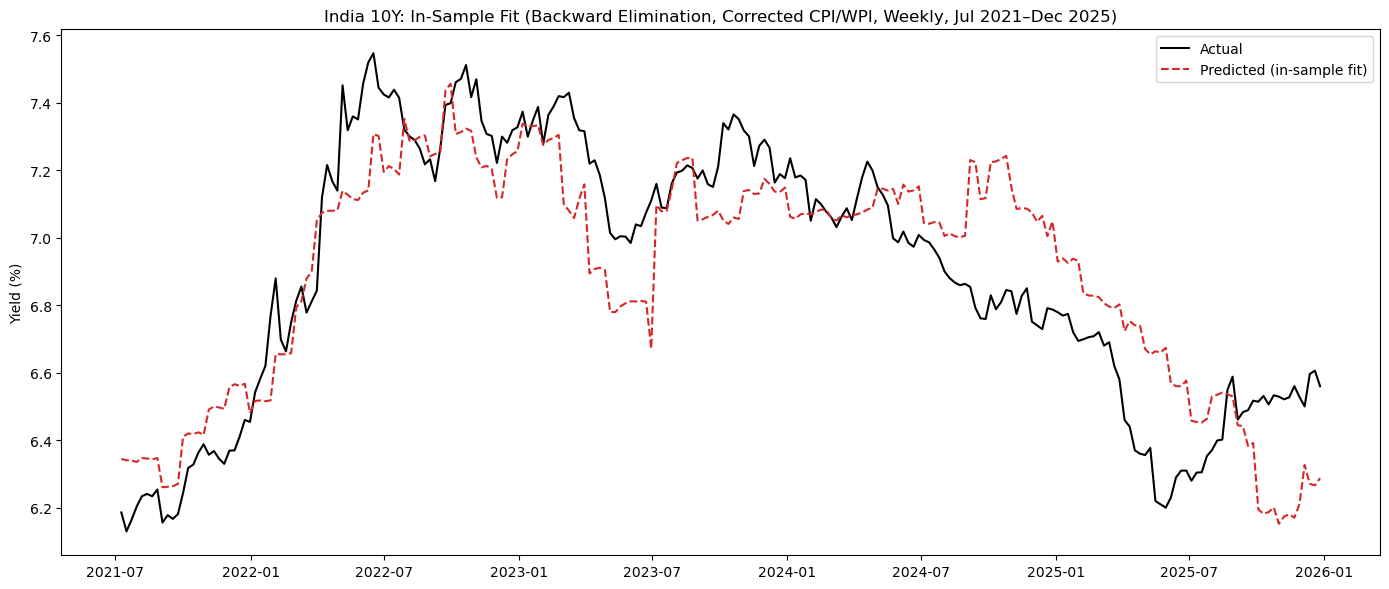

In-sample RMSE: 0.2005


In [13]:
fitted_values = final_model_backward.predict(sm.add_constant(final_vars_backward))

plt.figure(figsize=(14,6))
plt.plot(weekly_matrix_trimmed.index, y_trimmed, label='Actual', color='black', linewidth=1.5)
plt.plot(weekly_matrix_trimmed.index, fitted_values, label='Predicted (in-sample fit)', color='tab:red', linestyle='--')
plt.title('India 10Y: In-Sample Fit (Backward Elimination, Corrected CPI/WPI, Weekly, Jul 2021–Dec 2025)')
plt.ylabel('Yield (%)')
plt.legend()
plt.tight_layout()
plt.show()

in_sample_rmse = np.sqrt(mean_squared_error(y_trimmed, fitted_values))
print(f"In-sample RMSE: {in_sample_rmse:.4f}")

In [14]:
coefs = final_model_backward.params.to_dict()
model_vars = list(final_vars_backward.columns)

print("Final model variables:", model_vars)
print("\nFitted formula:")
formula = f"india_10y = {coefs['const']:.4f}"
for var in model_vars:
    sign = '+' if coefs[var] >= 0 else '-'
    formula += f" {sign} {abs(coefs[var]):.4f}*{var}"
print(formula)

print("\nCoefficients:")
for var in ['const'] + model_vars:
    print(f"  {var:12s} = {coefs[var]:.6f}")

Final model variables: ['m3_growth', 'us_10y', 'sofr', 'cpi', 'wpi']

Fitted formula:
india_10y = 5.4344 - 0.0467*m3_growth + 0.0706*us_10y + 0.2289*sofr + 0.1255*cpi + 0.0524*wpi

Coefficients:
  const        = 5.434438
  m3_growth    = -0.046745
  us_10y       = 0.070623
  sofr         = 0.228926
  cpi          = 0.125541
  wpi          = 0.052386


In [15]:
target_date = pd.Timestamp('2026-03-06')

# real values for this date, verified against source files and confirmed by you
real_inputs = {
    'm3_growth': 15.269540,   # Mar-2026, m3_growth.xlsx
    'us_10y': 4.15,           # 2026-03-06, DGS10.xlsx (confirmed)
    'sofr': 3.65,             # 2026-03-06, SOFR.xlsx (confirmed)
    'cpi': 3.402702,          # Mar-2026, inflation_data.xlsx (recomputed)
    'wpi': 3.976143,          # Mar-2026, inflation_data.xlsx (recomputed)
}

X_target = pd.DataFrame([real_inputs])[model_vars]
X_target = sm.add_constant(X_target, has_constant='add')

point_forecast = final_model_backward.predict(X_target).values[0]

print(f"Forecast date: {target_date.date()}")
print("Inputs used:")
for k in model_vars:
    print(f"  {k:12s} = {real_inputs[k]}")

print(f"\nPredicted india_10y: {point_forecast:.4f}%")

actual = 6.688  # real india_10y for 2026-03-06, verified by you
error = point_forecast - actual
print(f"Actual india_10y:    {actual}%")
print(f"Error (predicted - actual): {error:+.4f}  ({error/actual*100:+.2f}%)")

Forecast date: 2026-03-06
Inputs used:
  m3_growth    = 15.26954
  us_10y       = 4.15
  sofr         = 3.65
  cpi          = 3.402702
  wpi          = 3.976143

Predicted india_10y: 6.4848%
Actual india_10y:    6.688%
Error (predicted - actual): -0.2032  (-3.04%)


In [16]:
target_date = pd.Timestamp('2026-04-01')

# real values for this date, verified against source files
real_inputs = {
    'cpi': 3.484938,          # Apr-2026, inflation_data.xlsx (recomputed)
    'sofr': 3.65,             # 2026-04-01, SOFR.xlsx
    'us_10y': 4.33,           # 2026-04-01, DGS10.xlsx
    'm3_growth': 12.787560,   # Apr-2026, m3_growth.xlsx
    'wpi': 8.358209,          # Apr-2026, inflation_data.xlsx (recomputed)
}

X_target = pd.DataFrame([real_inputs])[model_vars]
X_target = sm.add_constant(X_target, has_constant='add')

point_forecast = final_model_backward.predict(X_target).values[0]

print(f"Forecast date: {target_date.date()}")
print("Inputs used:")
for k in model_vars:
    print(f"  {k:12s} = {real_inputs[k]}")

print(f"\nPredicted india_10y: {point_forecast:.4f}%")

actual = 6.960  
error = point_forecast - actual
print(f"Actual india_10y:    {actual}%")
print(f"Error (predicted - actual): {error:+.4f}  ({error/actual*100:+.2f}%)")

Forecast date: 2026-04-01
Inputs used:
  m3_growth    = 12.78756
  us_10y       = 4.33
  sofr         = 3.65
  cpi          = 3.484938
  wpi          = 8.358209

Predicted india_10y: 6.8534%
Actual india_10y:    6.96%
Error (predicted - actual): -0.1066  (-1.53%)


In [17]:
target_date = pd.Timestamp('2026-02-03')

real_inputs = {
    'cpi': 3.207659,
    'sofr': 3.69,
    'us_10y': 4.28,
    'm3_growth': 12.577414,
    'wpi': 2.180377,
}

X_target = pd.DataFrame([real_inputs])[model_vars]
X_target = sm.add_constant(X_target, has_constant='add')

point_forecast = final_model_backward.predict(X_target).values[0]

print(f"Forecast date: {target_date.date()}")
print("Inputs used:")
for k in model_vars:
    print(f"  {k:12s} = {real_inputs[k]}")

print(f"\nPredicted india_10y: {point_forecast:.4f}%")

actual = 6.721
error = point_forecast - actual
print(f"Actual india_10y:    {actual}%")
print(f"Error (predicted - actual): {error:+.4f}  ({error/actual*100:+.2f}%)")

Forecast date: 2026-02-03
Inputs used:
  m3_growth    = 12.577414
  us_10y       = 4.28
  sofr         = 3.69
  cpi          = 3.207659
  wpi          = 2.180377

Predicted india_10y: 6.5104%
Actual india_10y:    6.721%
Error (predicted - actual): -0.2106  (-3.13%)


In [18]:
def forecast_with_ci(inputs_dict, label=""):
    X = pd.DataFrame([inputs_dict])[model_vars]
    X = sm.add_constant(X, has_constant='add')
    
    point = final_model_backward.predict(X).values[0]
    pred = final_model_backward.get_prediction(X)
    ci = pred.summary_frame(alpha=0.05)
    
    print(f"Forecast {label}")
    print(f"Point estimate: {point:.4f}%")
    print(f"95% prediction interval: [{ci['obs_ci_lower'].values[0]:.4f}%, {ci['obs_ci_upper'].values[0]:.4f}%]")
    print(f"Interval width: {ci['obs_ci_upper'].values[0] - ci['obs_ci_lower'].values[0]:.4f} points")
    return point, ci

# example: re-run with confidence intervals on a date we already tested
apr1_inputs = {
    'cpi': 3.484938, 'sofr': 3.65, 'us_10y': 4.33,
    'm3_growth': 12.787560, 'wpi': 8.358209,
}
forecast_with_ci(apr1_inputs, label="2026-04-01")

Forecast 2026-04-01
Point estimate: 6.8534%
95% prediction interval: [6.4292%, 7.2776%]
Interval width: 0.8483 points


(np.float64(6.85341597137011),
        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
 0  6.853416  0.071149       6.713222        6.99361      6.429247   
 
    obs_ci_upper  
 0      7.277585  )

In [19]:
from sklearn.linear_model import LinearRegression

def forecast_linear_trend(series, weeks_ahead, lookback_weeks=None, freq='W-FRI'):
    """
    Fit y = a + b*t on the historical series (t = week index),
    then extrapolate `weeks_ahead` steps beyond the last known date.
    
    lookback_weeks: if set, only use the most recent N weeks of history
                     to fit the trend (instead of the full series).
    series must already be cut off at the training boundary (<=2025-12-31).
    """
    series = series.dropna()
    if lookback_weeks is not None:
        series = series.iloc[-lookback_weeks:]

    t = np.arange(len(series)).reshape(-1, 1)
    y = series.values

    reg = LinearRegression().fit(t, y)

    future_t = np.arange(len(series), len(series) + weeks_ahead).reshape(-1, 1)
    future_dates = pd.date_range(
        start=series.index[-1] + pd.Timedelta(weeks=1),
        periods=weeks_ahead, freq=freq
    )

    forecast_vals = reg.predict(future_t)
    return pd.Series(forecast_vals, index=future_dates, name=series.name)


def forecast_monthly_trend(weekly_series, weeks_ahead, lookback_months=3, freq='W-FRI'):
    """
    For monthly-frequency variables stored as forward-filled weekly series
    (cpi, wpi): fit the trend on the true underlying monthly values (not the
    duplicated weekly rows), forecast forward month by month, then broadcast
    each monthly forecast across the weekly Fridays that fall in that month —
    matching how the real data was originally constructed (.ffill()).
    Returns a weekly-indexed Series, same shape as forecast_linear_trend.
    """
    s = weekly_series.dropna()
    monthly = s.resample('MS').last()
    if lookback_months is not None:
        monthly = monthly.iloc[-lookback_months:]

    t = np.arange(len(monthly)).reshape(-1, 1)
    reg = LinearRegression().fit(t, monthly.values)

    last_month = monthly.index[-1]
    future_weeks = pd.date_range(
        start=s.index[-1] + pd.Timedelta(weeks=1),
        periods=weeks_ahead, freq=freq
    )

    forecasted = []
    for wk in future_weeks:
        month_start = wk.to_period('M').to_timestamp()
        months_ahead = (month_start.year - last_month.year) * 12 + (month_start.month - last_month.month)
        val = reg.predict([[len(monthly) - 1 + months_ahead]])[0]
        forecasted.append(val)

    return pd.Series(forecasted, index=future_weeks, name=weekly_series.name)

In [20]:
weeks_ahead = 12  # 12-week forecast horizon

forecasted_inputs = pd.DataFrame({
    'm3_growth': forecast_linear_trend(weekly_matrix_trimmed['m3_growth'], weeks_ahead, lookback_weeks=52),
    'us_10y':    forecast_linear_trend(weekly_matrix_trimmed['us_10y'], weeks_ahead, lookback_weeks=52),
    'sofr':      forecast_linear_trend(weekly_matrix_trimmed['sofr'], weeks_ahead, lookback_weeks=52),
    'cpi':       forecast_monthly_trend(weekly_matrix_trimmed['cpi'], weeks_ahead, lookback_months=3),
    'wpi':       forecast_monthly_trend(weekly_matrix_trimmed['wpi'], weeks_ahead, lookback_months=3),
})

print(forecasted_inputs)

            m3_growth    us_10y      sofr       cpi       wpi
2026-01-02   9.955739  4.052670  4.027715  1.693444  0.981360
2026-01-09   9.972213  4.043445  4.019639  1.693444  0.981360
2026-01-16   9.988687  4.034221  4.011563  1.693444  0.981360
2026-01-23  10.005160  4.024997  4.003487  1.693444  0.981360
2026-01-30  10.021634  4.015772  3.995411  1.693444  0.981360
2026-02-06  10.038108  4.006548  3.987335  2.257248  1.716657
2026-02-13  10.054582  3.997323  3.979259  2.257248  1.716657
2026-02-20  10.071055  3.988099  3.971182  2.257248  1.716657
2026-02-27  10.087529  3.978875  3.963106  2.257248  1.716657
2026-03-06  10.104003  3.969650  3.955030  2.821052  2.451954
2026-03-13  10.120477  3.960426  3.946954  2.821052  2.451954
2026-03-20  10.136951  3.951202  3.938878  2.821052  2.451954


In [21]:
X_forecast = sm.add_constant(forecasted_inputs[model_vars], has_constant='add')

pred = final_model_backward.get_prediction(X_forecast)
ci = pred.summary_frame(alpha=0.05)

forecast_table = forecasted_inputs.copy()
forecast_table['predicted_india_10y'] = ci['mean']
forecast_table['ci_lower'] = ci['obs_ci_lower']
forecast_table['ci_upper'] = ci['obs_ci_upper']

print(forecast_table)

            m3_growth    us_10y      sofr       cpi       wpi  \
2026-01-02   9.955739  4.052670  4.027715  1.693444  0.981360   
2026-01-09   9.972213  4.043445  4.019639  1.693444  0.981360   
2026-01-16   9.988687  4.034221  4.011563  1.693444  0.981360   
2026-01-23  10.005160  4.024997  4.003487  1.693444  0.981360   
2026-01-30  10.021634  4.015772  3.995411  1.693444  0.981360   
2026-02-06  10.038108  4.006548  3.987335  2.257248  1.716657   
2026-02-13  10.054582  3.997323  3.979259  2.257248  1.716657   
2026-02-20  10.071055  3.988099  3.971182  2.257248  1.716657   
2026-02-27  10.087529  3.978875  3.963106  2.257248  1.716657   
2026-03-06  10.104003  3.969650  3.955030  2.821052  2.451954   
2026-03-13  10.120477  3.960426  3.946954  2.821052  2.451954   
2026-03-20  10.136951  3.951202  3.938878  2.821052  2.451954   

            predicted_india_10y  ci_lower  ci_upper  
2026-01-02             6.441323  6.037074  6.845572  
2026-01-09             6.438053  6.033805  6.8

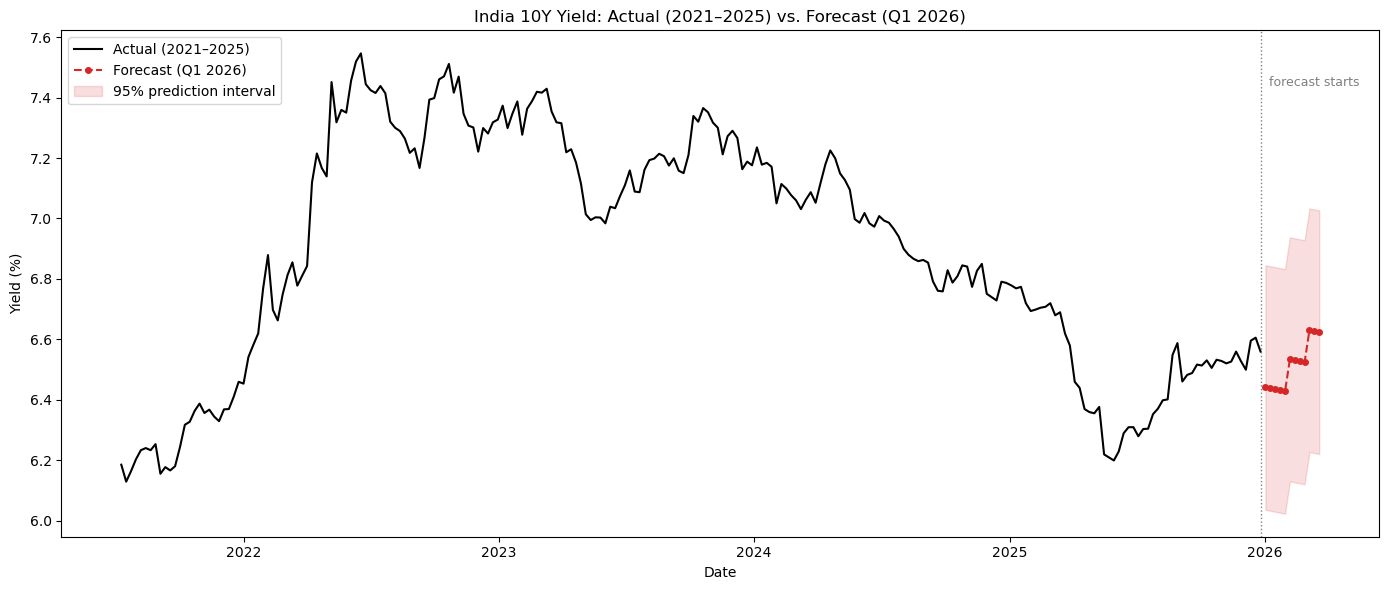

In [22]:
plt.figure(figsize=(14, 6))

# actual data through training cutoff
plt.plot(weekly_matrix_trimmed.index, y_trimmed, 
         label='Actual (2021–2025)', color='black', linewidth=1.5)

# forecasted path, Q1 2026
plt.plot(forecast_table.index, forecast_table['predicted_india_10y'], 
         label='Forecast (Q1 2026)', color='tab:red', linestyle='--', marker='o', markersize=4)

# 95% prediction interval band around the forecast
plt.fill_between(forecast_table.index, 
                  forecast_table['ci_lower'], forecast_table['ci_upper'],
                  color='tab:red', alpha=0.15, label='95% prediction interval')

# vertical line marking where real data ends and forecast begins
plt.axvline(weekly_matrix_trimmed.index[-1], color='gray', linestyle=':', linewidth=1)
plt.text(weekly_matrix_trimmed.index[-1], plt.ylim()[1]*0.98, '  forecast starts', 
         fontsize=9, color='gray', va='top')

plt.title('India 10Y Yield: Actual (2021–2025) vs. Forecast (Q1 2026)')
plt.ylabel('Yield (%)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

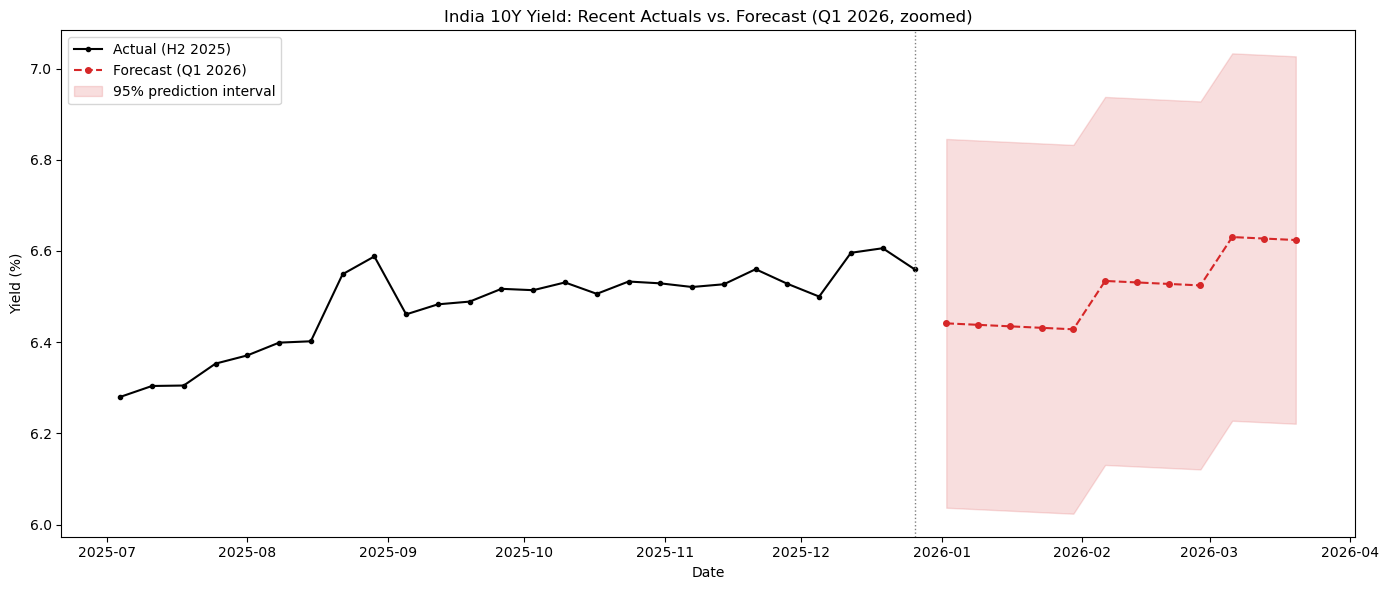

In [23]:
plt.figure(figsize=(14, 6))

recent_actual = y_trimmed[y_trimmed.index >= '2025-07-01']
plt.plot(recent_actual.index, recent_actual, 
         label='Actual (H2 2025)', color='black', linewidth=1.5, marker='o', markersize=3)

plt.plot(forecast_table.index, forecast_table['predicted_india_10y'], 
         label='Forecast (Q1 2026)', color='tab:red', linestyle='--', marker='o', markersize=4)

plt.fill_between(forecast_table.index, 
                  forecast_table['ci_lower'], forecast_table['ci_upper'],
                  color='tab:red', alpha=0.15, label='95% prediction interval')

plt.axvline(weekly_matrix_trimmed.index[-1], color='gray', linestyle=':', linewidth=1)

plt.title('India 10Y Yield: Recent Actuals vs. Forecast (Q1 2026, zoomed)')
plt.ylabel('Yield (%)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# --- SOFR (from SOFR.xlsx, 'Daily' sheet) ---
sofr_raw = pd.read_excel('C:/Users/Aditi Raj/Downloads/gsec/SOFR.xlsx', sheet_name='Daily', header=None)
sofr_raw.columns = ['date', 'sofr']
sofr_raw = sofr_raw.iloc[1:].copy()
sofr_raw['date'] = pd.to_datetime(sofr_raw['date'])
sofr_raw['sofr'] = pd.to_numeric(sofr_raw['sofr'], errors='coerce')
sofr_series = sofr_raw.dropna().set_index('date')['sofr'].sort_index()

# --- US 10Y (from us10y.xlsx, 'Daily' sheet) ---
us10y_raw = pd.read_excel('C:/Users/Aditi Raj/Downloads/gsec/us10y.xlsx', sheet_name='Daily', header=None)
us10y_raw.columns = ['date', 'us_10y']
us10y_raw = us10y_raw.iloc[1:].copy()
us10y_raw['date'] = pd.to_datetime(us10y_raw['date'])
us10y_raw['us_10y'] = pd.to_numeric(us10y_raw['us_10y'], errors='coerce')
us10y_series = us10y_raw.dropna().set_index('date')['us_10y'].sort_index()

full_range = pd.date_range('2021-07-01', '2026-07-31', freq='D')
sofr_weekly = sofr_series.reindex(full_range).ffill().resample('W-FRI').last()
us10y_weekly = us10y_series.reindex(full_range).ffill().resample('W-FRI').last()

# --- M3 growth (from m3_growth.xlsx, same logic as original notebook) ---
raw_m3_real = pd.read_excel('C:/Users/Aditi Raj/Downloads/gsec/m3 growth.xlsx', sheet_name='Report 1', header=None)
date_col_parsed = pd.to_datetime(raw_m3_real[1], errors='coerce')
first_data_row = date_col_parsed.first_valid_index()
data_m3_real = raw_m3_real.iloc[first_data_row:].copy()[[1, 34]]
data_m3_real.columns = ['date', 'm3']
data_m3_real['date'] = pd.to_datetime(data_m3_real['date'], errors='coerce')
data_m3_real['m3'] = pd.to_numeric(data_m3_real['m3'], errors='coerce')
data_m3_real = data_m3_real.dropna(subset=['date', 'm3']).sort_values('date')

m3_monthly_real = data_m3_real.set_index('date')['m3'].resample('ME').last()
m3_growth_real = (m3_monthly_real.pct_change(periods=12) * 100).dropna()
m3_weekly = m3_growth_real.reindex(full_range).ffill().resample('W-FRI').last()

# --- cpi / wpi (from inflation data.xlsx, same logic as original notebook) ---
raw_infl = pd.read_excel('C:/Users/Aditi Raj/Downloads/inflation data.xlsx', header=None)

cpi_s = raw_infl[[0, 1]].copy(); cpi_s.columns = ['date', 'value']
cpi_s['date'] = pd.to_datetime(cpi_s['date'], errors='coerce')
cpi_s['value'] = pd.to_numeric(cpi_s['value'], errors='coerce')
cpi_s = cpi_s.dropna().sort_values('date').set_index('date')['value']

wpi_s = raw_infl[[6, 7]].copy(); wpi_s.columns = ['date', 'value']
wpi_s['date'] = pd.to_datetime(wpi_s['date'], errors='coerce')
wpi_s['value'] = pd.to_numeric(wpi_s['value'], errors='coerce')
wpi_s = wpi_s.dropna().sort_values('date').set_index('date')['value']

cpi_yoy_real = (cpi_s.pct_change(periods=12) * 100).dropna()
wpi_yoy_real = (wpi_s.pct_change(periods=12) * 100).dropna()

cpi_weekly = cpi_yoy_real.reindex(full_range).ffill().resample('W-FRI').last()
wpi_weekly = wpi_yoy_real.reindex(full_range).ffill().resample('W-FRI').last()

# --- combine, restrict to the same weeks as forecast_table ---
q1_real = pd.DataFrame({
    'm3_growth': m3_weekly,
    'us_10y': us10y_weekly,
    'sofr': sofr_weekly,
    'cpi': cpi_weekly,
    'wpi': wpi_weekly,
}).reindex(forecast_table.index)

print(q1_real)

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


            m3_growth  us_10y  sofr       cpi       wpi
2026-01-02  12.111155    4.19  3.75  2.734337  1.186944
2026-01-09  12.111155    4.18  3.64  2.734337  1.186944
2026-01-16  12.111155    4.24  3.65  2.734337  1.186944
2026-01-23  12.111155    4.24  3.65  2.734337  1.186944
2026-01-30  12.111155    4.26  3.68  2.734337  1.186944
2026-02-06  12.027650    4.22  3.64  3.207659  2.180377
2026-02-13  12.027650    4.04  3.66  3.207659  2.180377
2026-02-20  12.027650    4.08  3.66  3.207659  2.180377
2026-02-27  12.027650    3.97  3.68  3.207659  2.180377
2026-03-06  12.577414    4.15  3.65  3.402702  3.976143
2026-03-13  12.577414    4.28  3.65  3.402702  3.976143
2026-03-20  12.577414    4.39  3.62  3.402702  3.976143


C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_26876\195346120.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_col_parsed = pd.to_datetime(raw_m3_real[1], errors='coerce')
C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_26876\195346120.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cpi_s['date'] = pd.to_datetime(cpi_s['date'], errors='coerce')
C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_26876\195346120.py:44: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wpi_s['date'] = pd.to_datetime(wpi_s['date'], errors='coerce')


In [25]:
X_real = sm.add_constant(q1_real[model_vars], has_constant='add')
actual_india_10y_from_inputs = final_model_backward.predict(X_real)

comparison_table = pd.DataFrame({
    'forecast_india_10y': forecast_table['predicted_india_10y'],
    'actual_india_10y_from_real_inputs': actual_india_10y_from_inputs,
})
comparison_table['error'] = comparison_table['forecast_india_10y'] - comparison_table['actual_india_10y_from_real_inputs']
print(comparison_table)

            forecast_india_10y  actual_india_10y_from_real_inputs     error
2026-01-02            6.441323                           6.428134  0.013189
2026-01-09            6.438053                           6.402246  0.035807
2026-01-16            6.434782                           6.408773  0.026010
2026-01-23            6.431512                           6.408773  0.022739
2026-01-30            6.428242                           6.417053  0.011189
2026-02-06            6.534271                           6.520438  0.013833
2026-02-13            6.531001                           6.512304  0.018697
2026-02-20            6.527730                           6.515129  0.012601
2026-02-27            6.524460                           6.511939  0.012521
2026-03-06            6.630489                           6.610644  0.019846
2026-03-13            6.627219                           6.619825  0.007394
2026-03-20            6.623949                           6.620725  0.003223


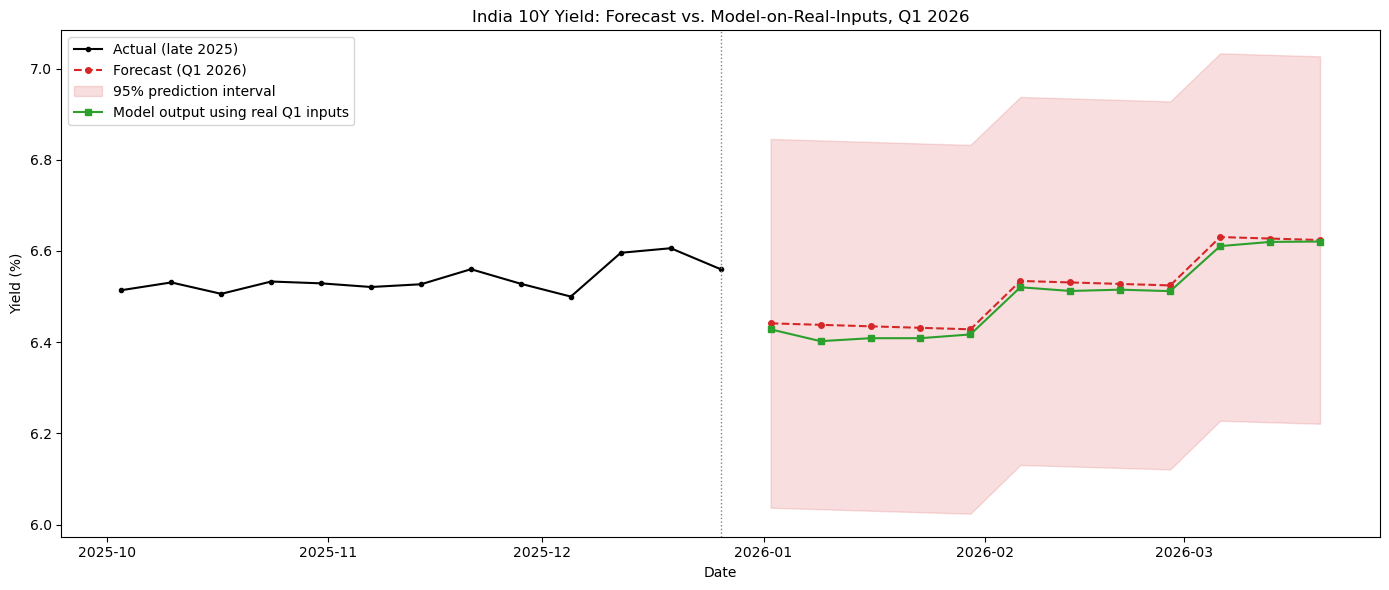

In [26]:
plt.figure(figsize=(14, 6))

# real actual yield history through Dec 2025
plt.plot(weekly_matrix_trimmed.index[-13:], y_trimmed[-13:], 
         label='Actual (late 2025)', color='black', linewidth=1.5, marker='o', markersize=3)

# forecasted path
plt.plot(forecast_table.index, forecast_table['predicted_india_10y'], 
         label='Forecast (Q1 2026)', color='tab:red', linestyle='--', marker='o', markersize=4)
plt.fill_between(forecast_table.index, forecast_table['ci_lower'], forecast_table['ci_upper'],
                  color='tab:red', alpha=0.15, label='95% prediction interval')

# what the model would say using the REAL Q1 2026 inputs (ground truth check)
plt.plot(comparison_table.index, comparison_table['actual_india_10y_from_real_inputs'],
          label='Model output using real Q1 inputs', color='tab:green', linestyle='-', marker='s', markersize=4)

plt.axvline(weekly_matrix_trimmed.index[-1], color='gray', linestyle=':', linewidth=1)
plt.title('India 10Y Yield: Forecast vs. Model-on-Real-Inputs, Q1 2026')
plt.ylabel('Yield (%)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
real_10y_raw = pd.read_csv('C:/Users/Aditi Raj/Downloads/gsec/q1 2026 10y.csv')
real_10y_raw['Date'] = pd.to_datetime(real_10y_raw['Date'], format='%d-%m-%Y')
real_10y_raw = real_10y_raw.sort_values('Date').set_index('Date')['Price']

full_range_2026 = pd.date_range('2026-01-01', '2026-03-31', freq='D')
real_10y_daily = real_10y_raw.reindex(full_range_2026).ffill()
real_10y_weekly = real_10y_daily.resample('W-FRI').last()

comparison_table['actual_india_10y_real'] = real_10y_weekly.reindex(comparison_table.index)
comparison_table['forecast_error'] = comparison_table['forecast_india_10y'] - comparison_table['actual_india_10y_real']
comparison_table['model_hindsight_error'] = comparison_table['actual_india_10y_from_real_inputs'] - comparison_table['actual_india_10y_real']

print(comparison_table)
print()
print("Forecast RMSE:", (comparison_table['forecast_error']**2).mean()**0.5)
print("Model hindsight RMSE:", (comparison_table['model_hindsight_error']**2).mean()**0.5)

            forecast_india_10y  actual_india_10y_from_real_inputs     error  \
2026-01-02            6.441323                           6.428134  0.013189   
2026-01-09            6.438053                           6.402246  0.035807   
2026-01-16            6.434782                           6.408773  0.026010   
2026-01-23            6.431512                           6.408773  0.022739   
2026-01-30            6.428242                           6.417053  0.011189   
2026-02-06            6.534271                           6.520438  0.013833   
2026-02-13            6.531001                           6.512304  0.018697   
2026-02-20            6.527730                           6.515129  0.012601   
2026-02-27            6.524460                           6.511939  0.012521   
2026-03-06            6.630489                           6.610644  0.019846   
2026-03-13            6.627219                           6.619825  0.007394   
2026-03-20            6.623949                      

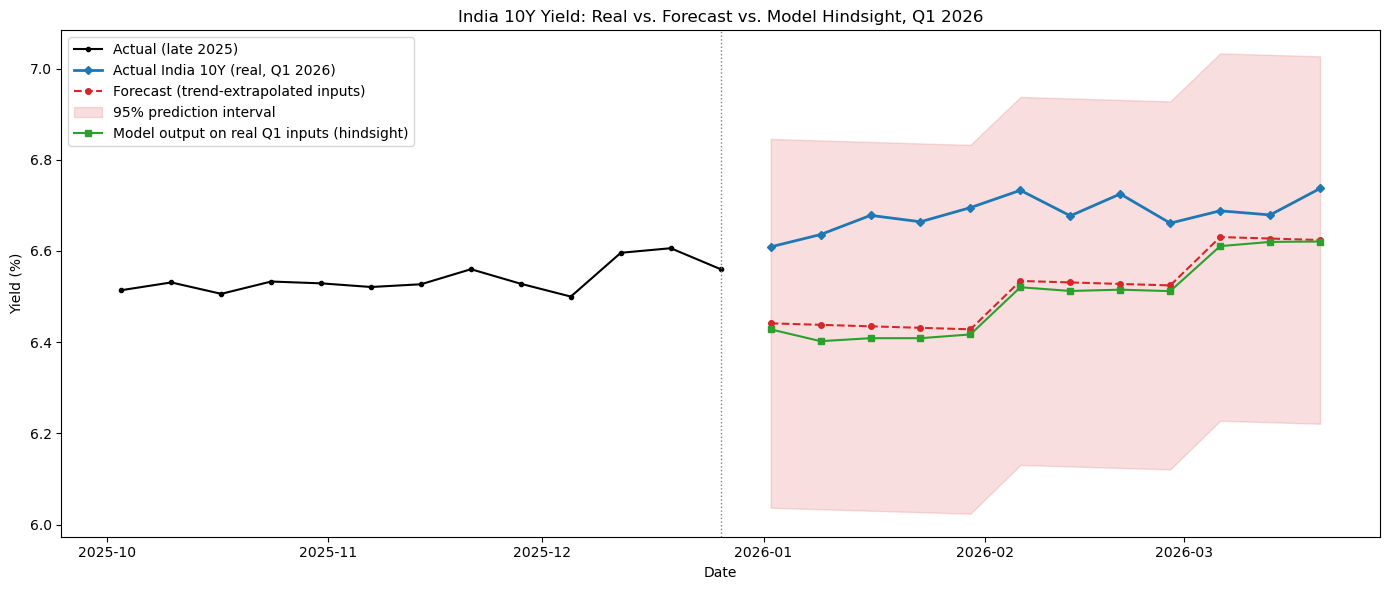

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(weekly_matrix_trimmed.index[-13:], y_trimmed[-13:], 
         label='Actual (late 2025)', color='black', linewidth=1.5, marker='o', markersize=3)

plt.plot(comparison_table.index, comparison_table['actual_india_10y_real'],
          label='Actual India 10Y (real, Q1 2026)', color='tab:blue', linewidth=2, marker='D', markersize=4)

plt.plot(forecast_table.index, forecast_table['predicted_india_10y'], 
         label='Forecast (trend-extrapolated inputs)', color='tab:red', linestyle='--', marker='o', markersize=4)
plt.fill_between(forecast_table.index, forecast_table['ci_lower'], forecast_table['ci_upper'],
                  color='tab:red', alpha=0.15, label='95% prediction interval')

plt.plot(comparison_table.index, comparison_table['actual_india_10y_from_real_inputs'],
          label='Model output on real Q1 inputs (hindsight)', color='tab:green', linestyle='-', marker='s', markersize=4)

plt.axvline(weekly_matrix_trimmed.index[-1], color='gray', linestyle=':', linewidth=1)
plt.title('India 10Y Yield: Real vs. Forecast vs. Model Hindsight, Q1 2026')
plt.ylabel('Yield (%)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
recent_bias = comparison_table['model_hindsight_error'].tail(4).mean()
print(f"Recent average bias: {recent_bias:.4f}")

comparison_table['forecast_bias_corrected'] = comparison_table['forecast_india_10y'] - recent_bias

Recent average bias: -0.1005


In [30]:
recent_bias = comparison_table['model_hindsight_error'].tail(4).mean()  # -0.1005
print(f"Recent average bias: {recent_bias:.4f}")

# correction: shift predictions up by the size of the underprediction
comparison_table['forecast_bias_corrected'] = comparison_table['forecast_india_10y'] - recent_bias
comparison_table['hindsight_bias_corrected'] = comparison_table['actual_india_10y_from_real_inputs'] - recent_bias

print(comparison_table[['forecast_india_10y', 'forecast_bias_corrected', 
                          'actual_india_10y_from_real_inputs', 'hindsight_bias_corrected',
                          'actual_india_10y_real']])

Recent average bias: -0.1005
            forecast_india_10y  forecast_bias_corrected  \
2026-01-02            6.441323                 6.541790   
2026-01-09            6.438053                 6.538520   
2026-01-16            6.434782                 6.535249   
2026-01-23            6.431512                 6.531979   
2026-01-30            6.428242                 6.528709   
2026-02-06            6.534271                 6.634738   
2026-02-13            6.531001                 6.631468   
2026-02-20            6.527730                 6.628197   
2026-02-27            6.524460                 6.624927   
2026-03-06            6.630489                 6.730956   
2026-03-13            6.627219                 6.727686   
2026-03-20            6.623949                 6.724415   

            actual_india_10y_from_real_inputs  hindsight_bias_corrected  \
2026-01-02                           6.428134                  6.528601   
2026-01-09                           6.402246        

In [31]:
recent_bias = comparison_table['model_hindsight_error'].tail(4).mean()
print(f"Bias estimated from last 4 known weeks (Feb 27 - Mar 20): {recent_bias:.4f}")

comparison_table['forecast_bias_corrected'] = comparison_table['forecast_india_10y'] - recent_bias
comparison_table['hindsight_bias_corrected'] = comparison_table['actual_india_10y_from_real_inputs'] - recent_bias

print(comparison_table[['forecast_india_10y', 'forecast_bias_corrected',
                          'actual_india_10y_from_real_inputs', 'hindsight_bias_corrected',
                          'actual_india_10y_real']])

corrected_forecast_rmse = ((comparison_table['forecast_bias_corrected'] - comparison_table['actual_india_10y_real'])**2).mean()**0.5
corrected_hindsight_rmse = ((comparison_table['hindsight_bias_corrected'] - comparison_table['actual_india_10y_real'])**2).mean()**0.5
print(f"\nOriginal forecast RMSE: {(comparison_table['forecast_error']**2).mean()**0.5:.4f}")
print(f"Bias-corrected forecast RMSE (retroactive, not a fair test): {corrected_forecast_rmse:.4f}")
print(f"Original hindsight RMSE: {(comparison_table['model_hindsight_error']**2).mean()**0.5:.4f}")
print(f"Bias-corrected hindsight RMSE (retroactive, not a fair test): {corrected_hindsight_rmse:.4f}")

Bias estimated from last 4 known weeks (Feb 27 - Mar 20): -0.1005
            forecast_india_10y  forecast_bias_corrected  \
2026-01-02            6.441323                 6.541790   
2026-01-09            6.438053                 6.538520   
2026-01-16            6.434782                 6.535249   
2026-01-23            6.431512                 6.531979   
2026-01-30            6.428242                 6.528709   
2026-02-06            6.534271                 6.634738   
2026-02-13            6.531001                 6.631468   
2026-02-20            6.527730                 6.628197   
2026-02-27            6.524460                 6.624927   
2026-03-06            6.630489                 6.730956   
2026-03-13            6.627219                 6.727686   
2026-03-20            6.623949                 6.724415   

            actual_india_10y_from_real_inputs  hindsight_bias_corrected  \
2026-01-02                           6.428134                  6.528601   
2026-01-09      

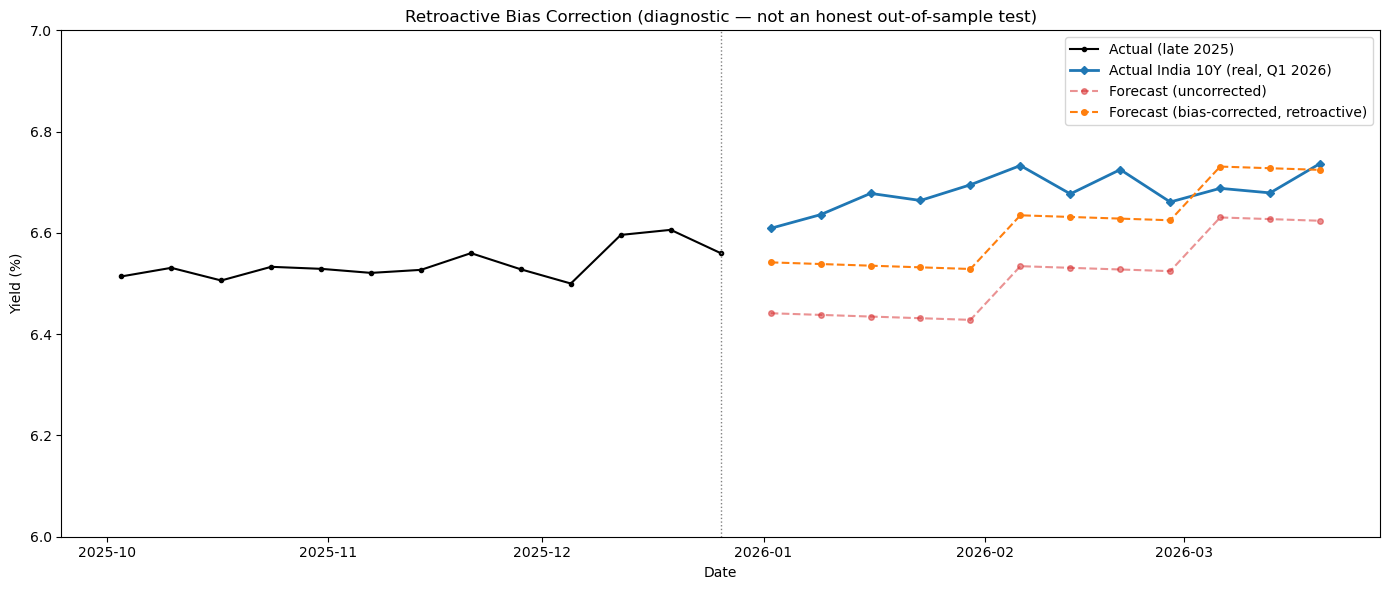

In [32]:
plt.figure(figsize=(14, 6))

plt.plot(weekly_matrix_trimmed.index[-13:], y_trimmed[-13:], 
         label='Actual (late 2025)', color='black', linewidth=1.5, marker='o', markersize=3)
plt.plot(comparison_table.index, comparison_table['actual_india_10y_real'],
          label='Actual India 10Y (real, Q1 2026)', color='tab:blue', linewidth=2, marker='D', markersize=4)
plt.plot(forecast_table.index, forecast_table['predicted_india_10y'], 
         label='Forecast (uncorrected)', color='tab:red', linestyle='--', marker='o', markersize=4, alpha=0.5)
plt.plot(comparison_table.index, comparison_table['forecast_bias_corrected'],
          label='Forecast (bias-corrected, retroactive)', color='tab:orange', linestyle='--', marker='o', markersize=4)

plt.axvline(weekly_matrix_trimmed.index[-1], color='gray', linestyle=':', linewidth=1)
plt.ylim(6.0, 7.0)   # <-- fixed scale, matches the earlier three-line chart

plt.title('Retroactive Bias Correction (diagnostic — not an honest out-of-sample test)')
plt.ylabel('Yield (%)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
def compute_fitness_metrics(predicted, actual, label=""):
    error = predicted - actual
    rmse = (error**2).mean()**0.5
    mae = error.abs().mean()
    mape = (error.abs() / actual.abs()).mean() * 100
    print(f"{label}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    print()
    return {'label': label, 'rmse': rmse, 'mae': mae, 'mape': mape}

results_forecast = compute_fitness_metrics(
    comparison_table['forecast_india_10y'], comparison_table['actual_india_10y_real'],
    label="Forecast vs. Real (trend-extrapolated inputs)")

results_hindsight = compute_fitness_metrics(
    comparison_table['actual_india_10y_from_real_inputs'], comparison_table['actual_india_10y_real'],
    label="Hindsight vs. Real (model on real Q1 inputs)")

fitness_summary = pd.DataFrame([results_forecast, results_hindsight]).set_index('label')
print(fitness_summary)

Forecast vs. Real (trend-extrapolated inputs)
  RMSE: 0.1800
  MAE:  0.1674
  MAPE: 2.51%

Hindsight vs. Real (model on real Q1 inputs)
  RMSE: 0.1966
  MAE:  0.1838
  MAPE: 2.75%

                                                   rmse       mae      mape
label                                                                      
Forecast vs. Real (trend-extrapolated inputs)  0.180000  0.167414  2.505824
Hindsight vs. Real (model on real Q1 inputs)   0.196598  0.183835  2.751916


In [34]:
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

resid = final_model_backward.resid
X_diag = final_model_backward.model.exog  # includes constant column

# Jarque-Bera: tests residual normality (H0: residuals are normally distributed)
jb_stat, jb_p, skew, kurtosis = jarque_bera(resid)
print("Jarque-Bera test (residual normality)")
print(f"  Statistic: {jb_stat:.4f}, p-value: {jb_p:.4f}")
print(f"  Skew: {skew:.4f}, Kurtosis: {kurtosis:.4f}")
print(f"  {'Residuals look normal (fail to reject H0)' if jb_p > 0.05 else 'Residuals deviate from normal (reject H0)'}")
print()

# Breusch-Pagan: tests for heteroscedasticity (H0: residual variance is constant)
bp_stat, bp_p, bp_f, bp_f_p = het_breuschpagan(resid, X_diag)
print("Breusch-Pagan test (heteroscedasticity)")
print(f"  LM Statistic: {bp_stat:.4f}, p-value: {bp_p:.4f}")
print(f"  {'No evidence of heteroscedasticity (fail to reject H0)' if bp_p > 0.05 else 'Evidence of heteroscedasticity (reject H0)'}")
print()

# VIF: tests for multicollinearity among predictors (>5-10 is typically concerning)
vif_data = pd.DataFrame()
vif_data['variable'] = final_vars_backward.columns
vif_data['VIF'] = [variance_inflation_factor(X_diag, i+1) for i in range(len(final_vars_backward.columns))]
print("Variance Inflation Factors (multicollinearity)")
print(vif_data)

Jarque-Bera test (residual normality)
  Statistic: 3.5534, p-value: 0.1692
  Skew: -0.1152, Kurtosis: 2.4420
  Residuals look normal (fail to reject H0)

Breusch-Pagan test (heteroscedasticity)
  LM Statistic: 37.7301, p-value: 0.0000
  Evidence of heteroscedasticity (reject H0)

Variance Inflation Factors (multicollinearity)
    variable        VIF
0  m3_growth   1.453124
1     us_10y   6.385801
2       sofr  20.561522
3        cpi   2.598198
4        wpi  15.351304


In [35]:
print("=== Model Fit Summary ===")
print(f"R-squared:          {final_model_backward.rsquared:.4f}")
print(f"Adj. R-squared:      {final_model_backward.rsquared_adj:.4f}")
print(f"F-statistic:         {final_model_backward.fvalue:.4f}")
print(f"Prob (F-statistic):  {final_model_backward.f_pvalue:.6f}")
print(f"  {'Model is jointly significant (reject H0: all coefs = 0)' if final_model_backward.f_pvalue < 0.05 else 'Model is NOT jointly significant'}")
print()

print("=== Individual Coefficient Significance ===")
coef_summary = pd.DataFrame({
    'coefficient': final_model_backward.params,
    'std_err': final_model_backward.bse,
    't_stat': final_model_backward.tvalues,
    'p_value': final_model_backward.pvalues,
})
coef_summary['significant_at_5%'] = coef_summary['p_value'] < 0.05
print(coef_summary)

=== Model Fit Summary ===
R-squared:          0.7379
Adj. R-squared:      0.7321
F-statistic:         128.3716
Prob (F-statistic):  0.000000
  Model is jointly significant (reject H0: all coefs = 0)

=== Individual Coefficient Significance ===
           coefficient   std_err     t_stat       p_value  significant_at_5%
const         5.434438  0.176675  30.759479  4.218868e-83               True
m3_growth    -0.046745  0.013514  -3.459043  6.468202e-04               True
us_10y        0.070623  0.033464   2.110411  3.591270e-02               True
sofr          0.228926  0.031001   7.384575  2.851076e-12               True
cpi           0.125541  0.011975  10.483548  3.051891e-21               True
wpi           0.052386  0.008610   6.084504  4.892756e-09               True


In [36]:
comparison_table['forecast_gap_bps'] = (comparison_table['forecast_india_10y'] - comparison_table['actual_india_10y_real']) * 100
comparison_table['hindsight_gap_bps'] = (comparison_table['actual_india_10y_from_real_inputs'] - comparison_table['actual_india_10y_real']) * 100

bps_table = comparison_table[['actual_india_10y_real', 
                                'forecast_india_10y', 'forecast_gap_bps',
                                'actual_india_10y_from_real_inputs', 'hindsight_gap_bps']]
print(bps_table)

print()
print("=== Summary (basis points) ===")
print(f"Forecast avg gap:   {comparison_table['forecast_gap_bps'].mean():+.1f} bps")
print(f"Forecast max gap:   {comparison_table['forecast_gap_bps'].abs().max():.1f} bps")
print(f"Hindsight avg gap:  {comparison_table['hindsight_gap_bps'].mean():+.1f} bps")
print(f"Hindsight max gap:  {comparison_table['hindsight_gap_bps'].abs().max():.1f} bps")

            actual_india_10y_real  forecast_india_10y  forecast_gap_bps  \
2026-01-02                  6.609            6.441323        -16.767680   
2026-01-09                  6.636            6.438053        -19.794715   
2026-01-16                  6.678            6.434782        -24.321750   
2026-01-23                  6.664            6.431512        -23.248785   
2026-01-30                  6.695            6.428242        -26.675820   
2026-02-06                  6.733            6.534271        -19.872893   
2026-02-13                  6.677            6.531001        -14.599928   
2026-02-20                  6.725            6.527730        -19.726963   
2026-02-27                  6.661            6.524460        -13.653998   
2026-03-06                  6.688            6.630489         -5.751072   
2026-03-13                  6.679            6.627219         -5.178107   
2026-03-20                  6.737            6.623949        -11.305142   

            actual_india